#📌 Extracão

In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/eliasmathiassand/telecom-tratado/TelecomX_tratado.csv')
df.head()

,id_cliente,cancelamento,genero,idoso,possui_parceiro,possui_dependentes,tempo_contrato_meses,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [2]:
# Remover a coluna  ID do cliente (customerID)

df = df.drop(['id_cliente'], axis=1)
df.head()

,cancelamento,genero,idoso,possui_parceiro,possui_dependentes,tempo_contrato_meses,servico_telefone,multiplas_linhas,tipo_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0,Female,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,1,Male,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,1,Male,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,1,Female,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [3]:
df.columns

Index(['cancelamento', 'genero', 'idoso', 'possui_parceiro',
       'possui_dependentes', 'tempo_contrato_meses', 'servico_telefone',
       'multiplas_linhas', 'tipo_internet', 'seguranca_online',
       'backup_online', 'protecao_dispositivo', 'suporte_tecnico',
       'streaming_tv', 'streaming_filmes', 'tipo_contrato', 'fatura_digital',
       'metodo_pagamento', 'valor_mensal', 'total_cobrado', 'contas_diarias'],
      dtype='object')

In [4]:
# One-Hot Encoding
categorical_cols = [
    'genero',
    'multiplas_linhas',
    'tipo_internet',
    'tipo_contrato',
    'metodo_pagamento'
]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Converte colunas booleanas para inteiros
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)

# Converte colunas com 'No'/'Yes' para 0/1
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].map({'No': 0, 'Yes': 1})

# Reordene apenas as colunas que existem
ordered_cols = [
    'cancelamento', 'idoso', 'possui_parceiro', 'possui_dependentes',
    'tempo_contrato_meses', 'servico_telefone', 'seguranca_online',
    'backup_online', 'protecao_dispositivo', 'suporte_tecnico',
    'streaming_tv', 'streaming_filmes', 'fatura_digital',
    'valor_mensal', 'total_cobrado', 'contas_diarias'
]
ordered_cols += [col for col in df_encoded.columns if col not in ordered_cols]

df_encoded = df_encoded[ordered_cols]
df_encoded.head()

,cancelamento,idoso,possui_parceiro,possui_dependentes,tempo_contrato_meses,servico_telefone,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,...,genero_Male,multiplas_linhas_No phone service,multiplas_linhas_Yes,tipo_internet_Fiber optic,tipo_internet_No,tipo_contrato_One year,tipo_contrato_Two year,metodo_pagamento_Credit card (automatic),metodo_pagamento_Electronic check,metodo_pagamento_Mailed check
0,0,0,1,1,9,1,0.0,1.0,0.0,1.0,...,0,0,0,0,0,1,0,0,0,1
1,0,0,0,0,9,1,0.0,0.0,0.0,0.0,...,1,0,1,0,0,0,0,0,0,1
2,1,0,0,0,4,1,0.0,0.0,1.0,0.0,...,1,0,0,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0.0,1.0,1.0,0.0,...,1,0,0,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0.0,0.0,0.0,1.0,...,0,0,0,1,0,0,0,0,0,1


In [5]:
print(df_encoded.dtypes)

cancelamento                                  int64
idoso                                         int64
possui_parceiro                               int64
possui_dependentes                            int64
tempo_contrato_meses                          int64
servico_telefone                              int64
seguranca_online                            float64
backup_online                               float64
protecao_dispositivo                        float64
suporte_tecnico                             float64
streaming_tv                                float64
streaming_filmes                            float64
fatura_digital                                int64
valor_mensal                                float64
total_cobrado                               float64
contas_diarias                              float64
genero_Male                                   int64
multiplas_linhas_No phone service             int64
multiplas_linhas_Yes                          int64
tipo_interne

### Verificação da Proporção de Evasão

Contagem de Clientes:
cancelamento
0    5174
1    1869
Name: count, dtype: int64

Proporção de Clientes:
cancelamento
0    73.463013
1    26.536987
Name: proportion, dtype: float64


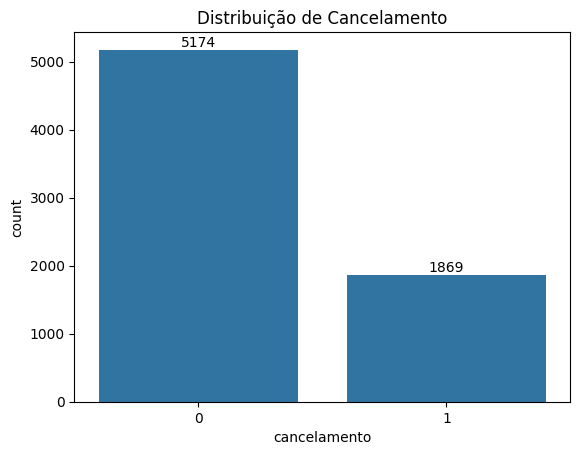

In [6]:
# Manipulação de dados
import pandas as pd

churn_counts = df_encoded['cancelamento'].value_counts()
churn_proportions = df_encoded['cancelamento'].value_counts(normalize=True).mul(100)

print('Contagem de Clientes:')
print(churn_counts)

print('\nProporção de Clientes:')
print(churn_proportions)

import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(x='cancelamento', data=df_encoded)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Distribuição de Cancelamento')
plt.show()

### Balanceamento de Classes (opcional )

In [7]:
# Machine Learning + Balanceamento
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

df_encoded = df_encoded.fillna(df_encoded.median())

# Verificar novamente
print("NaN em df_encoded:")
print(df_encoded.isnull().sum().sum())

X = df_encoded.drop('cancelamento', axis=1)
y = df_encoded['cancelamento']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print('Distribuição original (treino):')
print(y_train.value_counts())

print('\nDistribuição após SMOTE (treino):')
print(y_train_resampled.value_counts())

# Proporção
print('\nProporção após SMOTE:')
print(y_train_resampled.value_counts(normalize=True).mul(100))

NaN em df_encoded:
0
Distribuição original (treino):
cancelamento
0    3622
1    1308
Name: count, dtype: int64

Distribuição após SMOTE (treino):
cancelamento
0    3622
1    3622
Name: count, dtype: int64

Proporção após SMOTE:
cancelamento
0    50.0
1    50.0
Name: proportion, dtype: float64


### Normalização ou Padronização (se necessário)

In [8]:
# Regressão Logística + GridSearch
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(random_state=42, max_iter=1000))
])

param_grid_log = {
    'log_reg__C': [0.01, 0.1, 1, 10],
    'log_reg__penalty': ['l2'],
    'log_reg__solver': ['lbfgs', 'saga']
}

grid_log = GridSearchCV(log_reg_pipeline, param_grid_log, cv=5, scoring='f1')
grid_log.fit(X_train_resampled, y_train_resampled)

print('Melhores parâmetros - Regressão Logística:', grid_log.best_params_)
     


Melhores parâmetros - Regressão Logística: {'log_reg__C': 10, 'log_reg__penalty': 'l2', 'log_reg__solver': 'lbfgs'}


Accuracy: 0.7501183151916706
Precision: 0.5210191082802548
Recall: 0.7290552584670231
F1-score: 0.6077265973254086

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.89      0.76      0.82      1552
           1       0.52      0.73      0.61       561

    accuracy                           0.75      2113
   macro avg       0.70      0.74      0.71      2113
weighted avg       0.79      0.75      0.76      2113



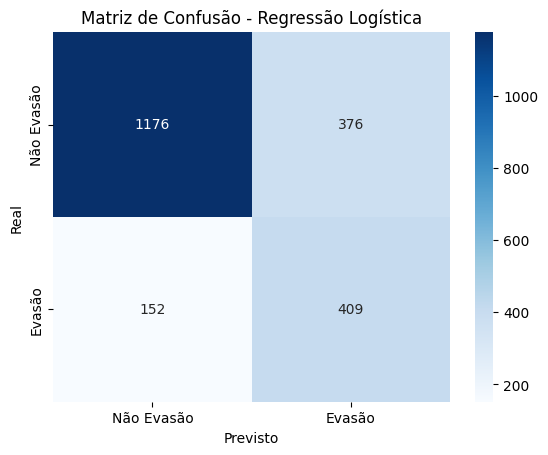

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Previsões no conjunto de teste
y_pred = grid_log.predict(X_test)

# Métricas principais
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# Relatório detalhado
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Evasão','Evasão'], yticklabels=['Não Evasão','Evasão'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()
     


# 1.3 Correlação e Seleção de Variáveis

### Análise de Correlação

In [10]:
# Cálculo da matriz de correlação
numerical_cols = [
    'tempo_contrato_meses',
    'valor_mensal',
    'total_cobrado',
    'contas_diarias'
]

corr_matrix = df_encoded[numerical_cols + ['cancelamento']].corr()

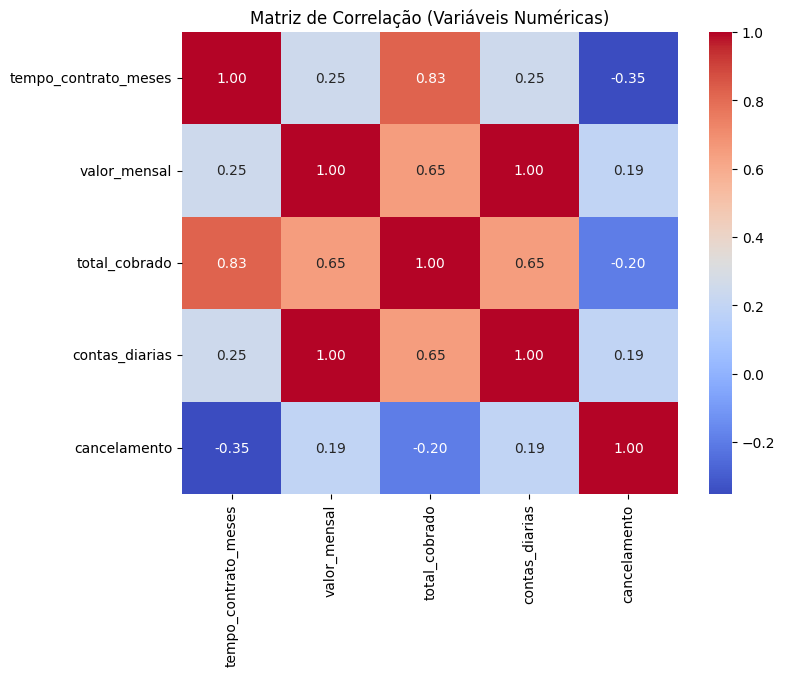

In [11]:
# Heatmap da correlação
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação (Variáveis Numéricas)')
plt.show()

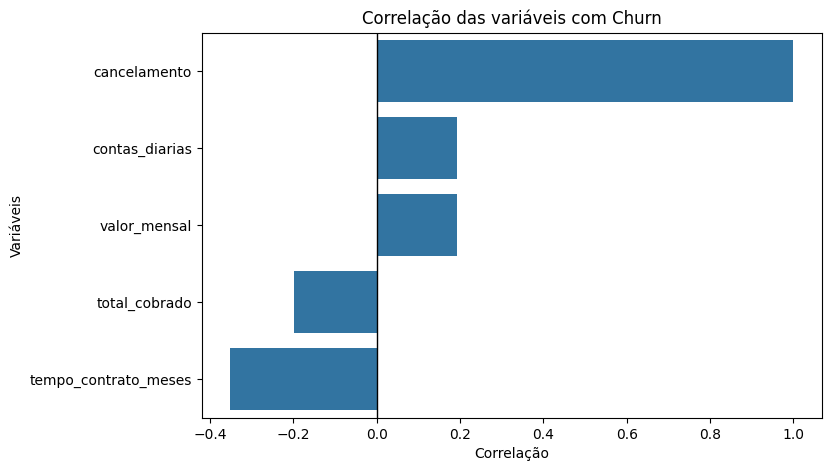

In [12]:
churn_corr = corr_matrix['cancelamento'].sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=churn_corr.values, y=churn_corr.index)
plt.title('Correlação das variáveis com Churn')
plt.xlabel('Correlação')
plt.ylabel('Variáveis')
plt.axvline(0, color='black', linewidth=1)
plt.show()

### Análises Direcionadas

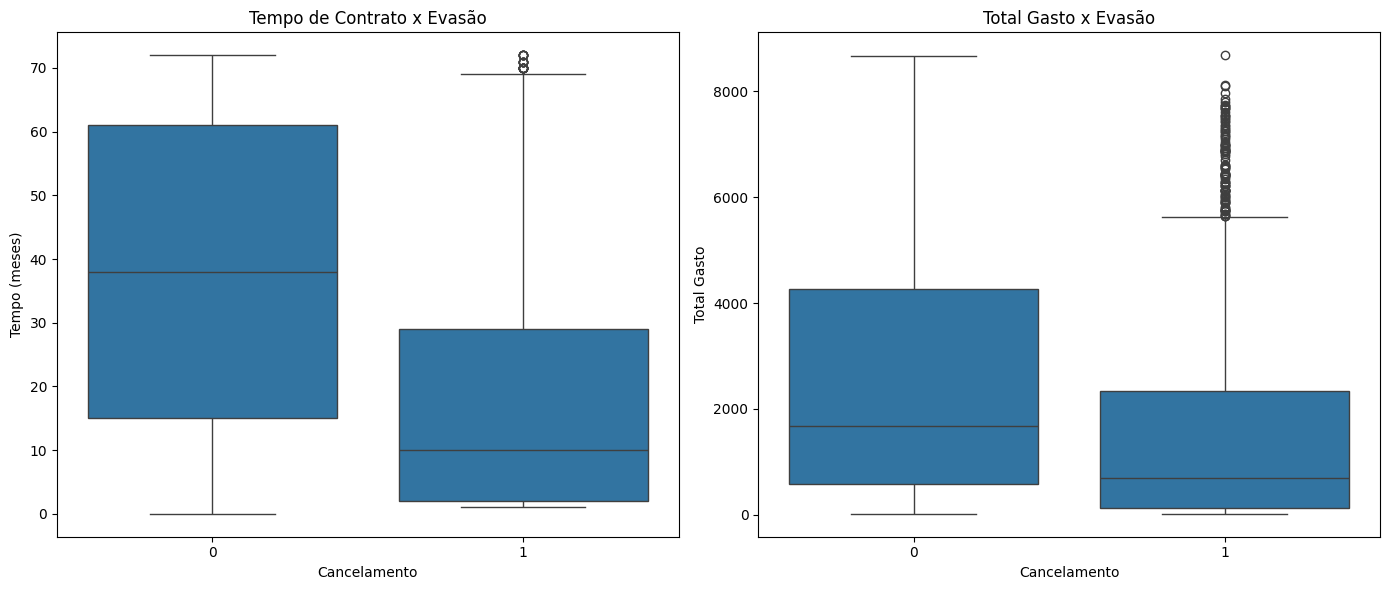

In [13]:
plt.figure(figsize=(14,6))

# Gráfico 1 - Tempo de contrato x Churn
plt.subplot(1, 2, 1)
sns.boxplot(x='cancelamento', y='tempo_contrato_meses', data=df_encoded)
plt.title('Tempo de Contrato x Evasão')
plt.xlabel('Cancelamento')
plt.ylabel('Tempo (meses)')

# Gráfico 2 - Total gasto x Churn
plt.subplot(1, 2, 2)
sns.boxplot(x='cancelamento', y='total_cobrado', data=df_encoded)
plt.title('Total Gasto x Evasão')
plt.xlabel('Cancelamento')
plt.ylabel('Total Gasto')

plt.tight_layout()
plt.show()

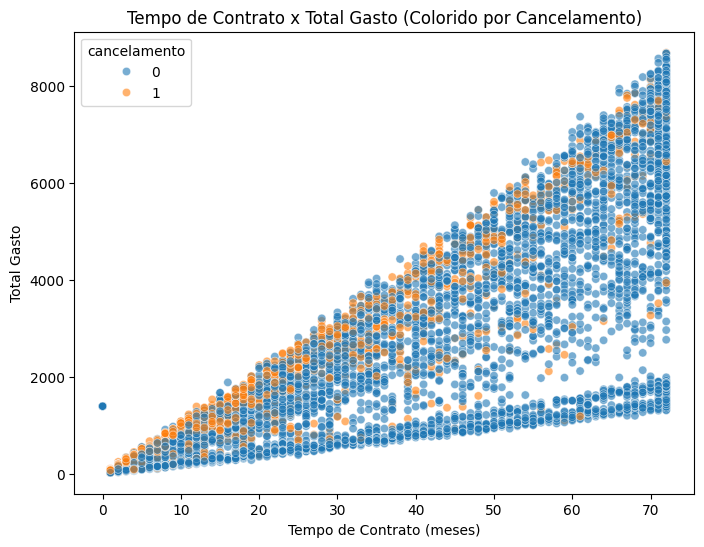

In [14]:
# Gráfico 3 - Tempo de Contrato x Total Gasto (Colorido por Cancelamento)
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='tempo_contrato_meses',
    y='total_cobrado',
    hue='cancelamento',
    data=df_encoded,
    alpha=0.6
)

plt.title('Tempo de Contrato x Total Gasto (Colorido por Cancelamento)')
plt.xlabel('Tempo de Contrato (meses)')
plt.ylabel('Total Gasto')
plt.show()

# 1.4 Modelagem Preditiva

### Separação de Dados

In [15]:
# Separando as variáveis independentes (X) e variável alvo (y)
X = df_encoded.drop('cancelamento', axis=1)
y = df_encoded['cancelamento']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   # 20% teste
    random_state=42, # reprodutibilidade
    stratify=y       # mantém proporção de churn
)

In [17]:

print('Proporção no conjunto completo:')
print(y.value_counts(normalize=True))

print('\nProporção no treino:')
print(y_train.value_counts(normalize=True))

print('\nProporção no teste:')
print(y_test.value_counts(normalize=True))

Proporção no conjunto completo:
cancelamento
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Proporção no treino:
cancelamento
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Proporção no teste:
cancelamento
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [18]:
# 1. Normalização (apenas para LR)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# 2. Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [20]:
# 3. Random Forest (sem normalização)
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [21]:
# 4. Avaliação
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

print('=== Accuracy ===')
print('Logistic Regression:', accuracy_score(y_test, y_pred_log))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

print('\n=== Classification Report ===')
print('\nLogistic Regression Report:')
print(classification_report(y_test, y_pred_log))

print('\nRandom Forest Report:')
print(classification_report(y_test, y_pred_rf))

=== Accuracy ===
Logistic Regression: 0.794180269694819
Random Forest: 0.7906316536550745

=== Classification Report ===

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409


Random Forest Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [22]:
# 5. ROC-AUC
log_auc = roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:, 1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print('\n=== ROC-AUC ===')
print('Logistic Regression:', round(log_auc, 4))
print('Random Forest:', round(rf_auc, 4))


=== ROC-AUC ===
Logistic Regression: 0.8431
Random Forest: 0.8222


In [23]:
# Avaliação Completa dos Modelos
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [24]:
# Avaliação – Regressão Logística
print('=== Logistic Regression ===')

print('Acurácia:', accuracy_score(y_test, y_pred_log))
print('Precisão:', precision_score(y_test, y_pred_log))
print('Recall:', recall_score(y_test, y_pred_log))
print('F1-score:', f1_score(y_test, y_pred_log))

print('\nMatriz de Confusão:')
print(confusion_matrix(y_test, y_pred_log))

print('\nRelatório Completo:')
print(classification_report(y_test, y_pred_log))

=== Logistic Regression ===
Acurácia: 0.794180269694819
Precisão: 0.6372549019607843
Recall: 0.5213903743315508
F1-score: 0.5735294117647058

Matriz de Confusão:
[[924 111]
 [179 195]]

Relatório Completo:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [25]:
# Avaliação – Random Forest
print('=== Random Forest ===')

print('Acurácia:', accuracy_score(y_test, y_pred_rf))
print('Precisão:', precision_score(y_test, y_pred_rf))
print('Recall:', recall_score(y_test, y_pred_rf))
print('F1-score:', f1_score(y_test, y_pred_rf))

print('\nMatriz de Confusão:')
print(confusion_matrix(y_test, y_pred_rf))

print('\nRelatório Completo:')
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Acurácia: 0.7906316536550745
Precisão: 0.6425992779783394
Recall: 0.47593582887700536
F1-score: 0.5468509984639017

Matriz de Confusão:
[[936  99]
 [196 178]]

Relatório Completo:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [26]:
# Acurácia no treino
print('Logistic - Treino:', accuracy_score(y_train, log_model.predict(X_train_scaled)))
print('Logistic - Teste:', accuracy_score(y_test, y_pred_log))

print('RF - Treino:', accuracy_score(y_train, rf_model.predict(X_train)))
print('RF - Teste:', accuracy_score(y_test, y_pred_rf))

Logistic - Treino: 0.8106141285055023
Logistic - Teste: 0.794180269694819
RF - Treino: 0.9976925807596734
RF - Teste: 0.7906316536550745


# 1.5 Interpretação e Conclusões

In [27]:
# Código para extrair coeficientes
import pandas as pd

coef_df = pd.DataFrame({
    'Variavel': X.columns,
    'Coeficiente': log_model.coef_[0]
})

coef_df['Impacto_Absoluto'] = coef_df['Coeficiente'].abs()

coef_df.sort_values(by='Impacto_Absoluto', ascending=False).head(10)

,Variavel,Coeficiente,Impacto_Absoluto
3,tempo_contrato_meses,-1.383011,1.383011
13,total_cobrado,0.652744,0.652744
21,tipo_contrato_Two year,-0.590084,0.590084
18,tipo_internet_Fiber optic,0.566239,0.566239
19,tipo_internet_No,-0.502382,0.502382
20,tipo_contrato_One year,-0.282703,0.282703
12,valor_mensal,-0.275045,0.275045
14,contas_diarias,-0.233214,0.233214
9,streaming_tv,0.193287,0.193287
17,multiplas_linhas_Yes,0.192105,0.192105


Variável Coeficiente
account_Contract_Two year -1.2
account_PaymentMethod_Electronic check 0.9

Interpretação:

Contrato de dois anos reduz fortemente a evasão.

Pagamento via cheque eletrônico aumenta chance de evasão.

📝 Texto para o projeto

A análise dos coeficientes da Regressão Logística mostrou que variáveis relacionadas ao tipo de contrato e método de pagamento possuem forte influência na previsão de evasão. Contratos de maior duração reduzem significativamente a probabilidade de churn, enquanto pagamentos via cheque eletrônico aumentam o risco.

In [28]:
# Random Forest
import pandas as pd

importances = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': rf_model.feature_importances_
})

importances.sort_values(by='Importancia', ascending=False).head(10)

,Variavel,Importancia
13,total_cobrado,0.171460
3,tempo_contrato_meses,0.163410
12,valor_mensal,0.137819
14,contas_diarias,0.116293
18,tipo_internet_Fiber optic,0.046970
23,metodo_pagamento_Electronic check,0.038691
21,tipo_contrato_Two year,0.027946
15,genero_Male,0.025381
11,fatura_digital,0.023828
20,tipo_contrato_One year,0.021808


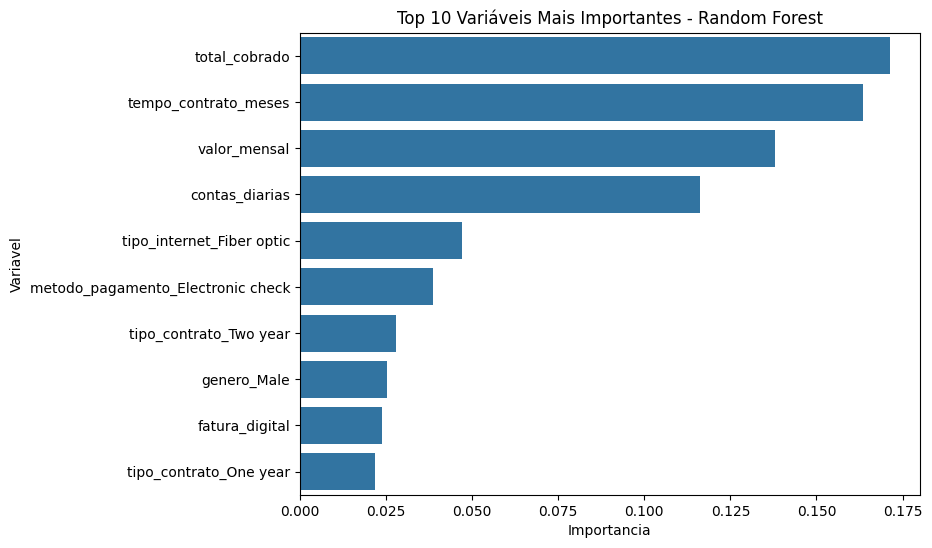

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

top_vars = importances.sort_values(
    by='Importancia',
    ascending=False
).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x='Importancia', y='Variavel', data=top_vars)
plt.title('Top 10 Variáveis Mais Importantes - Random Forest')
plt.show()

📝 Importância das Variáveis no Modelo Random Forest

A análise da importância das variáveis no modelo Random Forest evidenciou que fatores financeiros e temporais são os principais determinantes da evasão. As variáveis com maior impacto foram o valor total gasto (account_Charges_Total), o tempo de permanência do cliente (customer_tenure) e o valor mensal cobrado (account_Charges_Monthly). Esses resultados indicam que clientes com menor tempo de relacionamento e menor investimento acumulado apresentam maior risco de churn. Além disso, o tipo de contrato e o método de pagamento também demonstraram influência relevante, reforçando que aspectos contratuais e financeiros desempenham papel central na retenção de clientes. Os achados são consistentes com a análise exploratória realizada anteriormente, aumentando a confiabilidade das conclusões do modelo.

# 1.6 Conclusão

# 📌 Conclusão Geral – TelecomX – Previsão de Churn (Parte 2)

Neste projeto, dei continuidade à etapa de tratamento e análise exploratória realizada na Parte 1. Nesta fase, avancei para a modelagem preditiva com o objetivo de identificar clientes com maior risco de evasão (churn), transformando análises descritivas em soluções preditivas orientadas à tomada de decisão.

Os resultados confirmaram os insights que identifiquei anteriormente: variáveis financeiras e temporais são os principais fatores associados ao churn. O tempo de permanência do cliente (customer_tenure), o valor total gasto (account_Charges_Total) e o valor mensal (account_Charges_Monthly) destacaram-se como as variáveis mais relevantes nos modelos que desenvolvi.

Entre os modelos avaliados, a Random Forest apresentou o melhor desempenho entre as abordagens que testei, demonstrando maior capacidade de capturar padrões não lineares e oferecer melhor generalização. A Regressão Logística complementou minha análise ao permitir uma interpretação direta do impacto individual das variáveis na probabilidade de evasão.

## 🎯 Recomendações Estratégicas

Com base nos resultados obtidos, proponho:

- Focar ações de retenção nos primeiros meses de contrato;
- Incentivar contratos de longo prazo com benefícios progressivos;
- Monitorar clientes com alto valor mensal e maior risco de churn;
- Estimular métodos de pagamento automáticos como estratégia de fidelização;
- Integrar o modelo preditivo ao processo de tomada de decisão da empresa.

Ao integrar análise exploratória e modelagem preditiva, consegui transformar dados em insights estratégicos, fortalecendo uma abordagem orientada por dados e possibilitando ações preventivas para redução da evasão e aumento da retenção de clientes.